# Nonlinear regression: PyTorch vs. a custom neural network

Fit noisy nonlinear data with PyTorch first, then with this project's NumPy implementation, and compare their results. The models use identical starting parameters and full-batch gradient descent updates.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from sklearn.model_selection import train_test_split

# Add the parent directory to path to import custom modules
sys.path.insert(0, str(Path.cwd().parent))

from core.Sequential import Sequential
from layers.Linear import Linear
from layers.ReLu import ReLu
from losses.MSELoss import MSELoss
from optimizers.SGD import SGD

np.random.seed(42)
torch.manual_seed(42)


In [2]:
# A curved target gives the hidden ReLU layers something to learn.
x = np.linspace(-2.0, 2.0, 240, dtype=np.float32).reshape(-1, 1)
y_clean = np.sin(2.0 * x) + 0.3 * x**2
y = y_clean + np.random.normal(0.0, 0.08, size=x.shape).astype(np.float32)

print(f"x shape: {x.shape}, x dtype: {x.dtype}")
print(f"y shape: {y.shape}, y dtype: {y.dtype}")

x shape: (240, 1), x dtype: float32
y shape: (240, 1), y dtype: float32


In [3]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(f"X_train shape: {X_train.shape}, X_train dtype: {X_train.dtype}")
print(f"X_test shape: {X_test.shape}, X_test dtype: {X_test.dtype}")
print(f"y_train shape: {y_train.shape}, y_train dtype: {y_train.dtype}")
print(f"y_test shape: {y_test.shape}, y_test dtype: {y_test.dtype}")

X_train shape: (192, 1), X_train dtype: float32
X_test shape: (48, 1), X_test dtype: float32
y_train shape: (192, 1), y_train dtype: float32
y_test shape: (48, 1), y_test dtype: float32


In [4]:
X_train_t = torch.from_numpy(X_train)
X_test_t = torch.from_numpy(X_test)
y_train_t = torch.from_numpy(y_train)
y_test_t = torch.from_numpy(y_test)

print(f"X_train_t shape: {X_train_t.shape}, X_train_t dtype: {X_train_t.dtype}")
print(f"y_train_t shape: {y_train_t.shape}, y_train_t dtype: {y_train_t.dtype}")
print(f"X_test_t shape: {X_test_t.shape}, X_test_t dtype: {X_test_t.dtype}")
print(f"y_test_t shape: {y_test_t.shape}, y_test_t dtype: {y_test_t.dtype}")

X_train_t shape: torch.Size([192, 1]), X_train_t dtype: torch.float32
y_train_t shape: torch.Size([192, 1]), y_train_t dtype: torch.float32
X_test_t shape: torch.Size([48, 1]), X_test_t dtype: torch.float32
y_test_t shape: torch.Size([48, 1]), y_test_t dtype: torch.float32


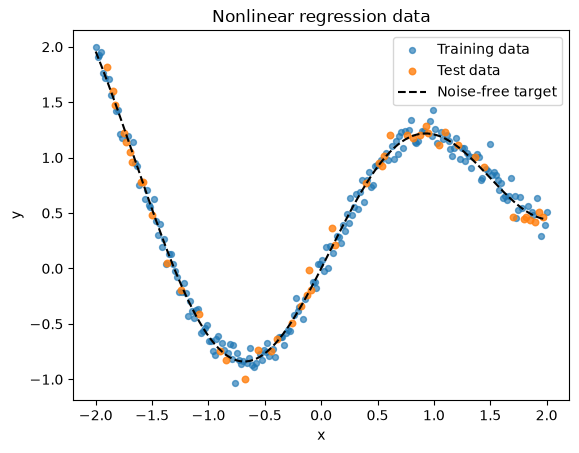

In [5]:
plt.scatter(X_train[:, 0], y_train[:, 0], s=18, alpha=0.65, label="Training data")
plt.scatter(X_test[:, 0], y_test[:, 0], s=22, alpha=0.8, label="Test data")
plt.plot(x[:, 0], y_clean[:, 0], "k--", label="Noise-free target")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Nonlinear regression data")
plt.legend()
plt.show()


## Train the PyTorch model


In [6]:
torch_model = nn.Sequential(
    nn.Linear(1, 32), 
    nn.ReLU(),
    nn.Linear(32, 32), 
    nn.ReLU(),
    nn.Linear(32, 1),
)

torch_loss = nn.MSELoss()
n_epochs = 3000
torch_optimizer = torch.optim.SGD(torch_model.parameters(), lr=0.01)
torch_history = []

for epoch in range(n_epochs):
    torch_model.train()
    torch_optimizer.zero_grad()
    prediction = torch_model(X_train_t)
    # The custom loss below is half-MSE, so use the same scaling here.
    loss = torch_loss(prediction, y_train_t)
    loss.backward()
    torch_optimizer.step()
    torch_history.append(loss.item())

    if (epoch + 1) % 300 == 0:
        print(f"Epoch {epoch + 1:4d}: PyTorch loss = {loss.item():.6f}")


Epoch  300: PyTorch loss = 0.135142
Epoch  600: PyTorch loss = 0.042866
Epoch  900: PyTorch loss = 0.020914
Epoch 1200: PyTorch loss = 0.012596
Epoch 1500: PyTorch loss = 0.009086
Epoch 1800: PyTorch loss = 0.007620
Epoch 2100: PyTorch loss = 0.006790
Epoch 2400: PyTorch loss = 0.006393
Epoch 2700: PyTorch loss = 0.006222
Epoch 3000: PyTorch loss = 0.006134


PyTorch test MSE: 0.007255


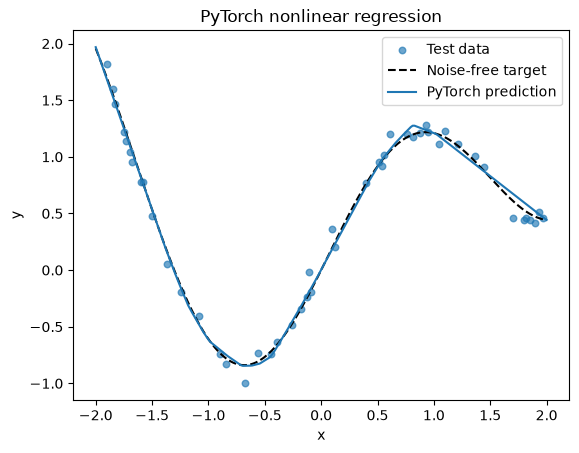

In [7]:
torch_model.eval()
with torch.no_grad():
    torch_test_pred = torch_model(X_test_t).numpy()
    torch_curve = torch_model(torch.from_numpy(x)).numpy()[:, 0]

torch_test_mse = np.mean((torch_test_pred - y_test) ** 2)
print(f"PyTorch test MSE: {torch_test_mse:.6f}")

plt.scatter(X_test[:, 0], y_test[:, 0], s=22, alpha=0.65, label="Test data")
plt.plot(x[:, 0], y_clean[:, 0], "k--", label="Noise-free target")
plt.plot(x[:, 0], torch_curve, label="PyTorch prediction")
plt.xlabel("x")
plt.ylabel("y")
plt.title("PyTorch nonlinear regression")
plt.legend()
plt.show()


## Train the custom model


In [8]:
custom_model = Sequential([
    Linear(1, 32), 
    ReLu(),
    Linear(32, 32), 
    ReLu(),
    Linear(32, 1),
])

custom_loss = MSELoss()
custom_optimizer = SGD(custom_model, lr=0.01)
custom_history = []
n_epochs = 3000

for epoch in range(n_epochs):
    prediction = custom_model.forward(X_train)
    loss = custom_loss.forward(prediction, y_train.T)
    custom_model.backward(custom_loss.backward())
    custom_optimizer.step()
    custom_history.append(loss)

    if (epoch + 1) % 300 == 0:
        print(f"Epoch {epoch + 1:4d}: custom loss = {loss:.6f}")


Epoch  300: custom loss = 0.290468
Epoch  600: custom loss = 0.119519
Epoch  900: custom loss = 0.041468
Epoch 1200: custom loss = 0.019715
Epoch 1500: custom loss = 0.012284
Epoch 1800: custom loss = 0.009298
Epoch 2100: custom loss = 0.007925
Epoch 2400: custom loss = 0.007210
Epoch 2700: custom loss = 0.006778
Epoch 3000: custom loss = 0.006519


Custom model test MSE: 0.008914


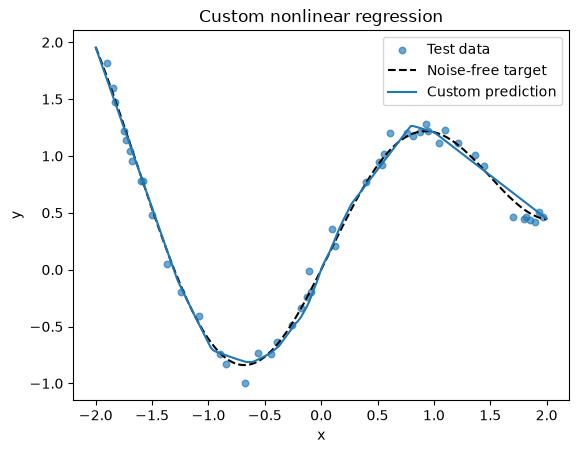

In [9]:
custom_test_pred = custom_model.forward(X_test).T
custom_curve = custom_model.forward(x).T[:, 0]
custom_test_mse = np.mean((custom_test_pred - y_test) ** 2)
print(f"Custom model test MSE: {custom_test_mse:.6f}")

plt.scatter(X_test[:, 0], y_test[:, 0], s=22, alpha=0.65, label="Test data")
plt.plot(x[:, 0], y_clean[:, 0], "k--", label="Noise-free target")
plt.plot(x[:, 0], custom_curve, label="Custom prediction")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Custom nonlinear regression")
plt.legend()
plt.show()


## Compare the results


PyTorch test MSE:              0.007255
Custom model test MSE:         0.008914
Maximum prediction difference: 9.81e-02


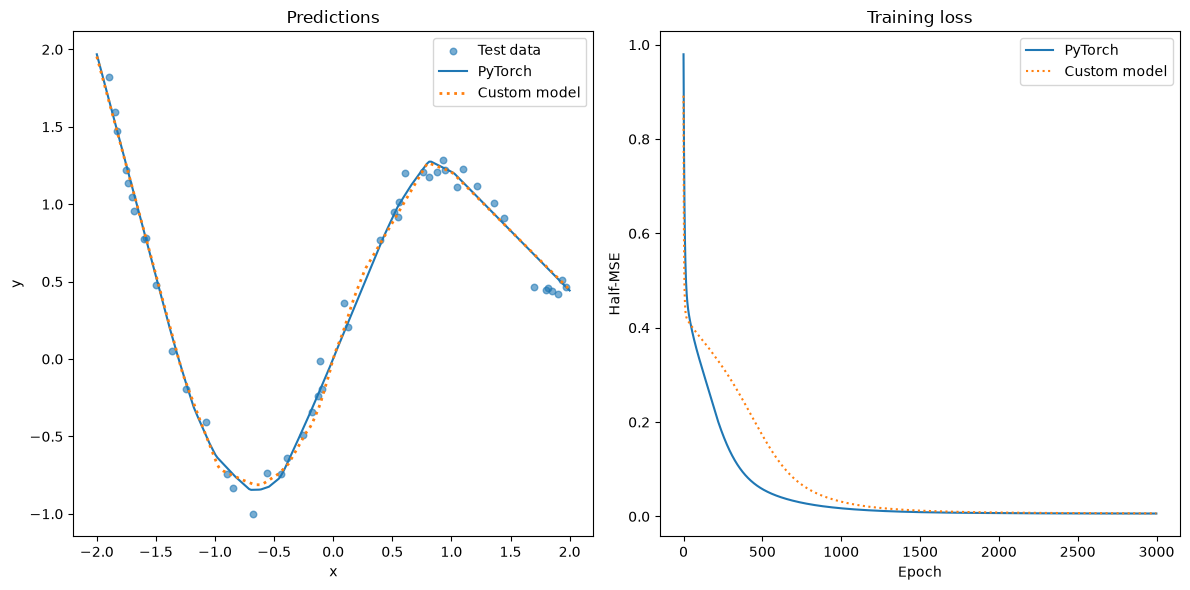

In [10]:
max_prediction_difference = np.max(np.abs(torch_test_pred - custom_test_pred))
print(f"PyTorch test MSE:              {torch_test_mse:.6f}")
print(f"Custom model test MSE:         {custom_test_mse:.6f}")
print(f"Maximum prediction difference: {max_prediction_difference:.2e}")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].scatter(X_test[:, 0], y_test[:, 0], s=22, alpha=0.6, label="Test data")
axes[0].plot(x[:, 0], torch_curve, label="PyTorch")
axes[0].plot(x[:, 0], custom_curve, ":", linewidth=2, label="Custom model")
axes[0].set(xlabel="x", ylabel="y", title="Predictions")
axes[0].legend()

axes[1].plot(torch_history, label="PyTorch")
axes[1].plot(custom_history, ":", label="Custom model")
axes[1].set(xlabel="Epoch", ylabel="Half-MSE", title="Training loss")
axes[1].legend()
fig.tight_layout()
plt.show()
